# 07 — Modélisation : Decision Tree

**Objectif** : entraîner et optimiser un arbre de décision pour la détection d'anomalies CBC, sur les deux configurations de features (Expérience A : 9 features, Expérience B1 : 5 features).

**Point d'attention spécifique** : sans contrainte, un Decision Tree peut overfitter complètement (apprendre le train par cœur). Le tuning de `max_depth`, `min_samples_split` et `min_samples_leaf` est donc essentiel pour obtenir un modèle qui généralise.

**Hypothèse à vérifier** : le label étant construit à partir de seuils sur chaque variable, un Decision Tree devrait très bien performer sur l'Expérience A (proche de reconstruire la règle exacte).

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import time
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from evaluation import evaluate_model, plot_confusion_matrices, results_table

os.makedirs('../models', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

RANDOM_STATE = 42

## 0. Chargement des données préparées (issues de l'étape 4)

In [2]:
X_train_A = pd.read_csv('../data/processed/X_train_A.csv')
X_test_A  = pd.read_csv('../data/processed/X_test_A.csv')
y_train_A = pd.read_csv('../data/processed/y_train_A.csv').squeeze()
y_test_A  = pd.read_csv('../data/processed/y_test_A.csv').squeeze()

X_train_B1 = pd.read_csv('../data/processed/X_train_B1.csv')
X_test_B1  = pd.read_csv('../data/processed/X_test_B1.csv')
y_train_B1 = pd.read_csv('../data/processed/y_train_B1.csv').squeeze()
y_test_B1  = pd.read_csv('../data/processed/y_test_B1.csv').squeeze()

print("Expérience A :", X_train_A.shape, X_test_A.shape)
print("Expérience B1:", X_train_B1.shape, X_test_B1.shape)

Expérience A : (419075, 9) (104769, 9)
Expérience B1: (419075, 5) (104769, 5)


## 1. Baseline — Decision Tree avec paramètres par défaut (aucune contrainte de profondeur)

Attention : sans `max_depth`, l'arbre peut grandir librement → risque fort d'overfitting, on s'attend à un écart visible entre score train et score test.

In [3]:
dt_A_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
model_A_base, y_pred_A_base, metrics_A_base = evaluate_model(
    dt_A_baseline, X_train_A, y_train_A, X_test_A, y_test_A,
    "DT baseline - Exp A"
)

dt_B1_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
model_B1_base, y_pred_B1_base, metrics_B1_base = evaluate_model(
    dt_B1_baseline, X_train_B1, y_train_B1, X_test_B1, y_test_B1,
    "DT baseline - Exp B1"
)

results_table([metrics_A_base, metrics_B1_base])

,Modèle,Accuracy,Precision,Recall,F1-score,Temps (s)
0,DT baseline - Exp A,0.998836,0.998531,0.997399,0.997964,5.15
1,DT baseline - Exp B1,0.827535,0.696491,0.704319,0.700383,4.06


In [4]:
# Vérification de l'overfitting : score train vs score test (baseline)
print("Profondeur réelle de l'arbre (Exp A):", model_A_base.get_depth())
print("Nombre de feuilles (Exp A):", model_A_base.get_n_leaves())
print("F1 train (Exp A):", f1_score(y_train_A, model_A_base.predict(X_train_A)))
print("F1 test  (Exp A):", f1_score(y_test_A, y_pred_A_base))

print("\nProfondeur réelle de l'arbre (Exp B1):", model_B1_base.get_depth())
print("Nombre de feuilles (Exp B1):", model_B1_base.get_n_leaves())
print("F1 train (Exp B1):", f1_score(y_train_B1, model_B1_base.predict(X_train_B1)))
print("F1 test  (Exp B1):", f1_score(y_test_B1, y_pred_B1_base))

Profondeur réelle de l'arbre (Exp A): 24
Nombre de feuilles (Exp A): 492
F1 train (Exp A): 1.0
F1 test  (Exp A): 0.997964495461826

Profondeur réelle de l'arbre (Exp B1): 56
Nombre de feuilles (Exp B1): 55244
F1 train (Exp B1): 0.9985262498695334
F1 test  (Exp B1): 0.7003830401114298


## 2. Recherche d'hyperparamètres — GridSearchCV (Expérience A)

Grille testée :
- `max_depth` : limite la profondeur (None = pas de limite)
- `min_samples_split` : nombre min d'échantillons pour diviser un nœud
- `min_samples_leaf` : nombre min d'échantillons dans une feuille
- `criterion` : `'gini'` ou `'entropy'`

In [5]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt_A = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_dt,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_dt_A.fit(X_train_A, y_train_A)
print(f"Temps de recherche: {time.time()-start:.1f}s")

print("\nMeilleurs paramètres (Exp A):", grid_dt_A.best_params_)
print("Meilleur F1-score (CV, Exp A):", grid_dt_A.best_score_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Temps de recherche: 391.9s

Meilleurs paramètres (Exp A): {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5}
Meilleur F1-score (CV, Exp A): 0.9986660357194446


## 3. Recherche d'hyperparamètres — GridSearchCV (Expérience B1)

In [6]:
grid_dt_B1 = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_dt,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_dt_B1.fit(X_train_B1, y_train_B1)
print(f"Temps de recherche: {time.time()-start:.1f}s")

print("\nMeilleurs paramètres (Exp B1):", grid_dt_B1.best_params_)
print("Meilleur F1-score (CV, Exp B1):", grid_dt_B1.best_score_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Temps de recherche: 324.0s

Meilleurs paramètres (Exp B1): {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Meilleur F1-score (CV, Exp B1): 0.7349867427923349


## 4. Évaluation finale des meilleurs modèles sur le TEST set

In [7]:
best_dt_A = grid_dt_A.best_estimator_
best_dt_B1 = grid_dt_B1.best_estimator_

y_pred_A = best_dt_A.predict(X_test_A)
y_pred_B1 = best_dt_B1.predict(X_test_B1)

results = []
for name, y_true, y_pred in [
    ("DT baseline - Exp A", y_test_A, y_pred_A_base),
    ("DT optimisé - Exp A", y_test_A, y_pred_A),
    ("DT baseline - Exp B1", y_test_B1, y_pred_B1_base),
    ("DT optimisé - Exp B1", y_test_B1, y_pred_B1),
]:
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
    })

df_results = results_table(results)
df_results

,Modèle,Accuracy,Precision,Recall,F1-score
0,DT baseline - Exp A,0.998836,0.998531,0.997399,0.997964
1,DT optimisé - Exp A,0.999227,0.999199,0.998099,0.998649
2,DT baseline - Exp B1,0.827535,0.696491,0.704319,0.700383
3,DT optimisé - Exp B1,0.835972,0.684035,0.793330,0.734640


## 5. Matrices de confusion (baseline vs optimisé, A vs B1)

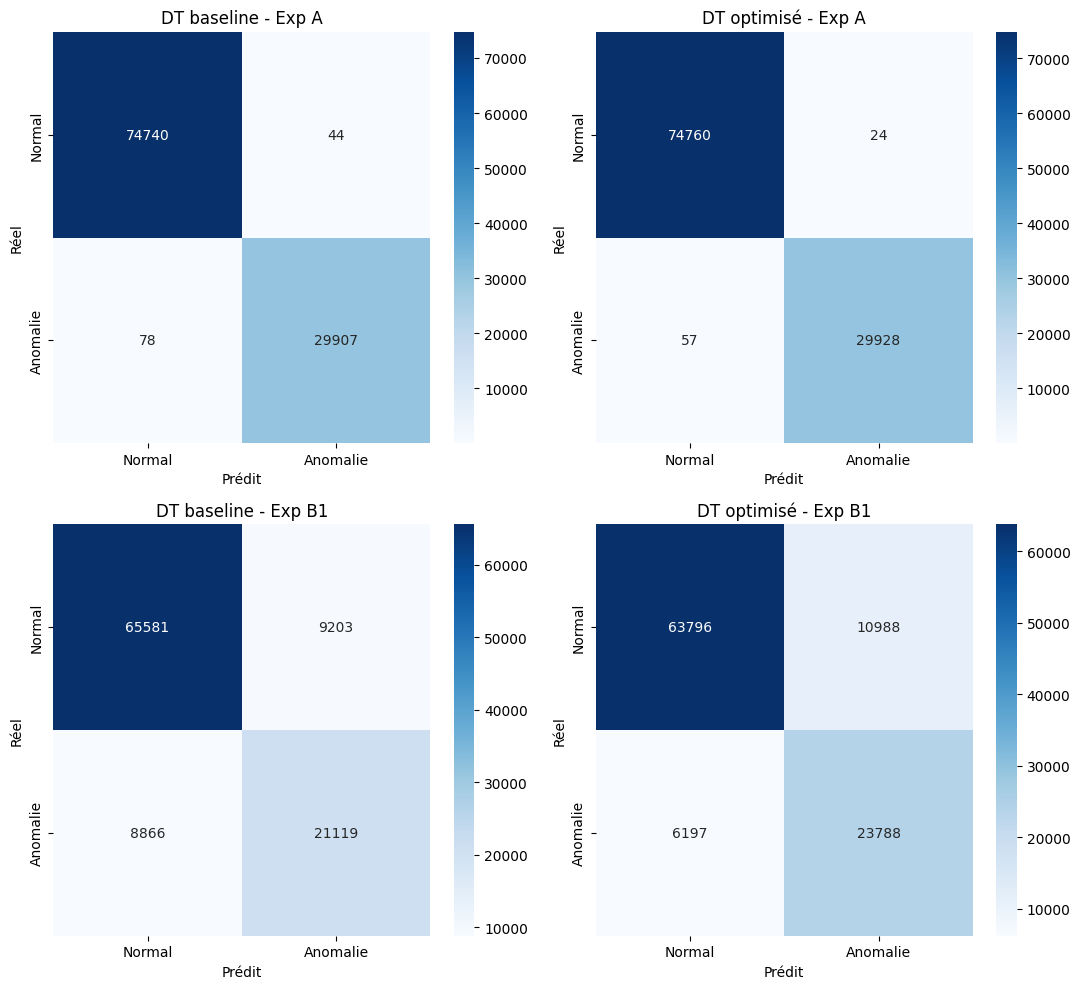

In [8]:
configs = [
    (y_test_A, y_pred_A_base, "DT baseline - Exp A"),
    (y_test_A, y_pred_A, "DT optimisé - Exp A"),
    (y_test_B1, y_pred_B1_base, "DT baseline - Exp B1"),
    (y_test_B1, y_pred_B1, "DT optimisé - Exp B1"),
]

plot_confusion_matrices(configs, save_path='../figures/confusion_matrices_dt.png')

## 6. Importance des variables (feature_importances_)

Contrairement aux coefficients de Logistic Regression, `feature_importances_` mesure combien chaque variable a contribué à réduire l'impureté globale de l'arbre — toujours positif, pas de signe (direction).

In [9]:
importance_A = pd.DataFrame({
    'Variable': X_train_A.columns,
    'Importance': best_dt_A.feature_importances_
}).sort_values('Importance', ascending=False)

importance_B1 = pd.DataFrame({
    'Variable': X_train_B1.columns,
    'Importance': best_dt_B1.feature_importances_
}).sort_values('Importance', ascending=False)

print("Importance des variables (Expérience A):")
print(importance_A)
print("\nImportance des variables (Expérience B1):")
print(importance_B1)

Importance des variables (Expérience A):
  Variable  Importance
3       HB    0.378247
2    LEUKO    0.162831
4      PLT    0.150241
0      ERY    0.080989
5      MCV    0.075519
7      MCH    0.058269
6     MCHC    0.048653
8      RDW    0.030851
1       HK    0.014399

Importance des variables (Expérience B1):
  Variable  Importance
0       HK    0.732701
2     MCHC    0.112198
1      MCV    0.106564
3      MCH    0.030720
4      RDW    0.017817


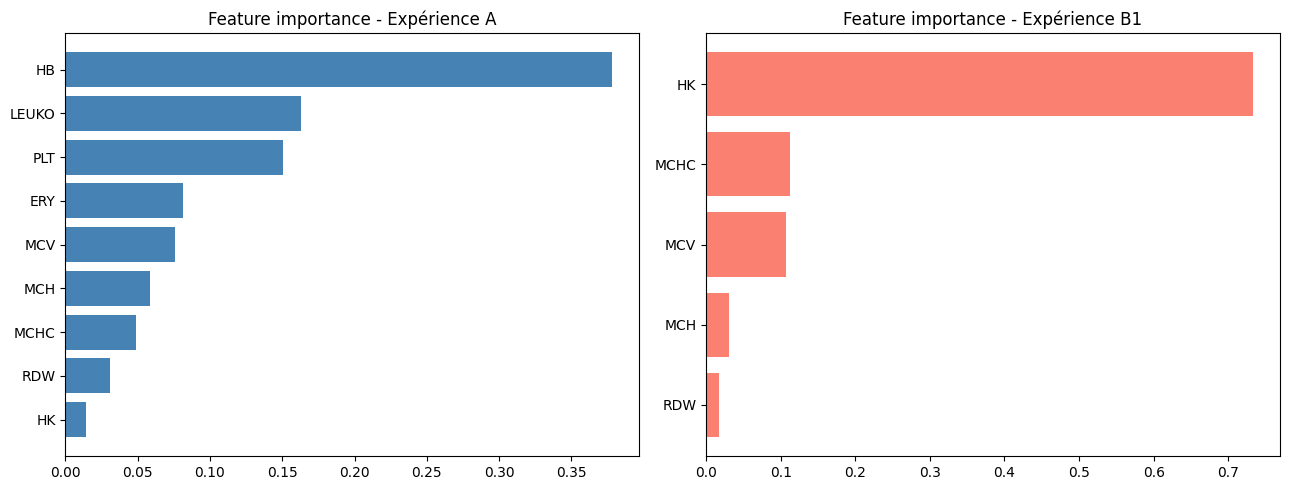

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(importance_A['Variable'], importance_A['Importance'], color='steelblue')
axes[0].set_title('Feature importance - Expérience A')
axes[0].invert_yaxis()

axes[1].barh(importance_B1['Variable'], importance_B1['Importance'], color='salmon')
axes[1].set_title('Feature importance - Expérience B1')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../figures/feature_importance_dt.png', dpi=150)
plt.show()

## 7. Visualisation de l'arbre (profondeur limitée pour la lisibilité)

Pour le rapport, on visualise une version de l'arbre limitée à `max_depth=3`, même si le modèle optimal retenu a une profondeur différente — cela reste lisible et donne une intuition claire des règles apprises.

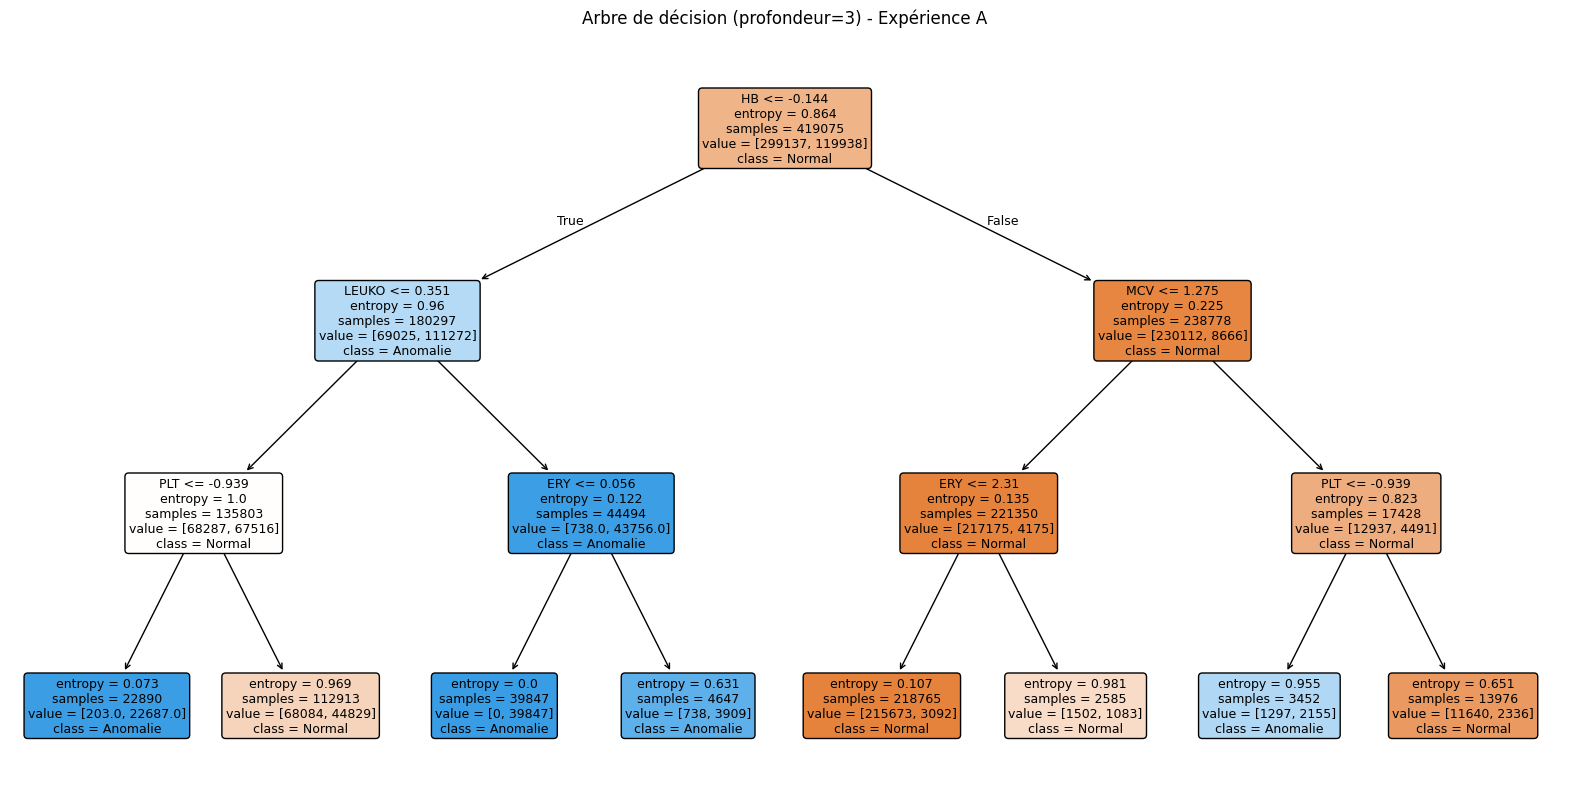

In [11]:
dt_viz_A = DecisionTreeClassifier(
    max_depth=3,
    criterion=best_dt_A.criterion,
    random_state=RANDOM_STATE
)
dt_viz_A.fit(X_train_A, y_train_A)

plt.figure(figsize=(20, 10))
plot_tree(dt_viz_A, feature_names=X_train_A.columns, class_names=['Normal', 'Anomalie'],
          filled=True, rounded=True, fontsize=9)
plt.title("Arbre de décision (profondeur=3) - Expérience A")
plt.savefig('../figures/decision_tree_viz_A.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Sauvegarde des modèles et résultats

In [12]:
joblib.dump(best_dt_A, '../models/dt_A_best.pkl')
joblib.dump(best_dt_B1, '../models/dt_B1_best.pkl')

df_results.to_csv('../data/processed/results_dt.csv', index=False)
print("✅ Modèles et résultats Decision Tree sauvegardés")

✅ Modèles et résultats Decision Tree sauvegardés


## Ce qu'il faut analyser pour le rapport

1. **Overfitting baseline** : l'écart F1 train vs F1 test du modèle baseline (sans contrainte) confirme-t-il un surapprentissage ? Le GridSearch a-t-il réduit cet écart ?
2. **`max_depth` retenu** : une valeur faible (3-7) suggère que peu de règles suffisent à bien séparer les classes ; une valeur élevée ou None suggère une structure plus complexe.
3. **Feature importance vs coefficients Logistic Regression** : les variables les plus importantes sont-elles cohérentes entre les deux modèles ? Cohérentes avec la pondération médicale de l'étape 3 ?
4. **Performance Exp A vs B1** : on s'attend à un Decision Tree très performant sur Exp A (proche de reconstruire la règle de seuils exacte du label) — vérifier si c'est bien le cas, et quantifier l'écart avec Exp B1.